In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("powerplant_data.csv")

In [3]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [5]:
X = df.drop("PE", axis=1)
y = df["PE"]

In [6]:
y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

In [7]:
# Split our data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
df.shape

(9568, 5)

In [9]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
import torch
import torch.nn as nn

In [11]:
X_train_tensor = torch.tensor(X_train_scaled, dtype = torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype = torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_scaled, dtype = torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype = torch.float32).view(-1, 1)

In [12]:
from torch.utils.data import TensorDataset, DataLoader
# Tensor Dataset converting
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [13]:
#Tensor DataLoader transfer
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 32)

### Deep Learning

In [14]:
# Build Our ANN Model
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            # 1st Hidden Layer
            nn.Linear(X_train.shape[1], 6),
            nn.ReLU(),
    
            # 2nd Hidden Layer
            nn.Linear(6, 6),
            nn.ReLU(),
    
            # o/p Layer
            nn.Linear(6, 1),
        )
    def forward(self, x):
        return self.model(x)

In [15]:
import torch.optim as optim

model = ANN()

#loss, optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [16]:
#Train the ANN
train_losses = []
val_losses = []

best_val_loss = float("inf")

epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0 #tot training loss for 1 epoch
    for xb, yb in train_loader:
        # xb = features of one batch
        # yb = labels of one batch
        optimizer.zero_grad()

        outputs = model(xb)

        loss = criterion(outputs, yb) # compute loss
        loss.backward() #back prop.... compute gradient
        optimizer.step() #Parameter update

        running_loss +=loss.item()  #loss is a tensor => py float
        
    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    # Validation
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():# no gradient compute
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = criterion(outputs, yb)

            running_val_loss += loss

        epoch_val_loss = running_val_loss / len(test_loader)
        val_losses.append(epoch_val_loss)

        print(f"epoch{epoch+1}/{epochs} ==> training loss = {epoch_train_loss} & val_loss = {epoch_val_loss}")

        if(epoch_val_loss < best_val_loss):
            best_val_loss = epoch_val_loss
            torch.save(model.state_dict(), "best_model.pt")

epoch1/100 ==> training loss = 206828.34446614582 & val_loss = 205921.75
epoch2/100 ==> training loss = 202065.32122395834 & val_loss = 194864.828125
epoch3/100 ==> training loss = 181270.79095052084 & val_loss = 164069.984375
epoch4/100 ==> training loss = 142083.4562174479 & val_loss = 119007.359375
epoch5/100 ==> training loss = 96693.23391927083 & val_loss = 76017.734375
epoch6/100 ==> training loss = 60691.71297200521 & val_loss = 47526.29296875
epoch7/100 ==> training loss = 39309.17569986979 & val_loss = 31587.564453125
epoch8/100 ==> training loss = 27119.30744628906 & val_loss = 22538.396484375
epoch9/100 ==> training loss = 20203.04765218099 & val_loss = 17415.822265625
epoch10/100 ==> training loss = 16042.426472981771 & val_loss = 14077.99609375
epoch11/100 ==> training loss = 12974.896948242187 & val_loss = 11272.3369140625
epoch12/100 ==> training loss = 10201.814199320475 & val_loss = 8723.6806640625
epoch13/100 ==> training loss = 7783.536737060547 & val_loss = 6497.525

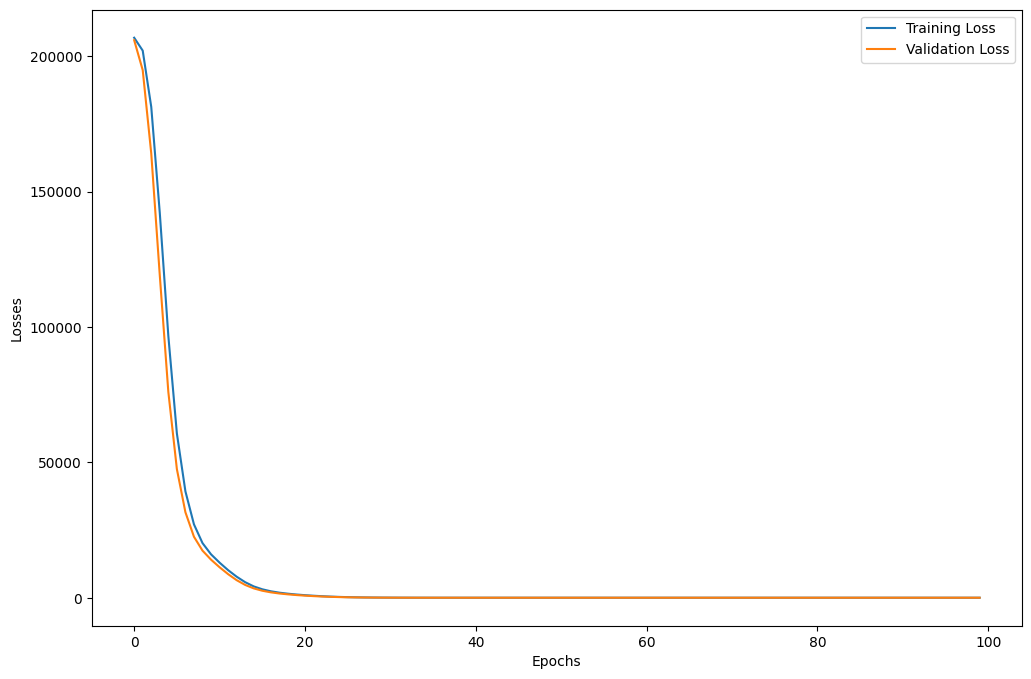

In [17]:
import matplotlib.pyplot as plt
loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})

plt.figure(figsize = (12, 8))
plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [18]:
# Loading the best model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [19]:
# Evaluation
model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

    train_mse_loss = criterion(train_preds, y_train_tensor)
    test_mse_loss = criterion(test_preds, y_test_tensor)

print("Training MSE:", train_mse_loss.item())
print("Testing MSE:", test_mse_loss.item())

Training MSE: 20.44835662841797
Testing MSE: 18.821510314941406


In [20]:
from sklearn.metrics import r2_score

print("R^2 score=",r2_score(y_test, test_preds))

R^2 score= 0.9342236789514134


In [21]:
predicted_df = pd.DataFrame(test_preds.numpy(), columns=["Predicted_Values"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual_Values"])

pd.concat([predicted_df, actual_df], axis=1)

,Predicted_Values,Actual_Values
0,435.189819,433.27
1,437.136353,438.16
2,461.321869,458.42
3,476.439972,480.82
4,435.262299,441.41
...,...,...
1909,451.469208,456.70
1910,431.698151,438.04
1911,467.596893,467.80
1912,431.174774,437.14
